# Ejercicio 7 - Indicadores y tablero

Este notebook es el registro de los indicadores: para cada uno muestra la pregunta,
su justificacion, la consulta SQL, el resultado, el grafico y la interpretacion.
Al final reune todos los graficos en un tablero.

- **Consultas:** `sql/06_indicadores.sql` (una consulta nombrada por indicador).
- **Datos:** `data/processed/taxi.duckdb`, construida por `scripts/build_indicadores.py`
  a partir de `sql/05_modelo_indicadores.sql`.
- **Documentacion:** `docs/ejercicio_7_indicadores.md` (se regenera con el mismo script).
- **Tablero en Metabase:** <http://localhost:3000>.

Si cambian los datos (por ejemplo al agregar 2025), primero se reconstruye la base:

```bash
docker compose stop metabase
docker compose exec -T lab python scripts/build_indicadores.py
docker compose start metabase
```

In [1]:
from lab_utils import BASE_INDICADORES, conectar, indicador, tablero

con = conectar(BASE_INDICADORES)   # solo lectura
resultados = {}

## Modelo de datos

La tabla `viajes` une Yellow y Green de todos los anios descargados con nombres de
columna comunes. La vista `viajes_validos` aplica el criterio de viaje plausible
(fecha dentro del anio, duracion entre 0 y 6 h, distancia positiva y total no negativo).

In [2]:
con.execute("""
    SELECT v.anio, v.tipo_taxi, v.registros, w.validos,
           round(100.0 * w.validos / v.registros, 2) AS pct_validos
    FROM (SELECT anio, tipo_taxi, count(*) AS registros FROM viajes GROUP BY ALL) v
    JOIN (SELECT anio, tipo_taxi, count(*) AS validos FROM viajes_validos GROUP BY ALL) w
      USING (anio, tipo_taxi)
    ORDER BY anio, tipo_taxi
""").df()

,anio,tipo_taxi,registros,validos,pct_validos
0,2024,green,660218,621641,94.16
1,2024,yellow,41169720,39810674,96.70
2,2025,green,591375,561980,95.03
3,2025,yellow,48722602,45873800,94.15
4,2026,green,337114,323240,95.88
5,2026,yellow,29703355,28237465,95.06


## 7.1 Preguntas

| # | Tema | Pregunta |
|---|---|---|
| 1 | Duracion del viaje segun numero de pasajeros | Llevar mas pasajeros aumenta el tiempo de viaje? |
| 2 | Duracion promedio del viaje por mes | Cuanto dura en promedio un viaje y como cambia entre meses, anios y servicios? |
| 3 | Tarifa base segun forma de pago | Con que forma de pago la tarifa base es mas alta? |
| 4 | Tarifa base segun origen de la solicitud | Los viajes pedidos por plataforma (Uber, Lyft u otras) tienen una tarifa base mas alta que los demas? |
| 5 | Propina segun distancia del viaje | Los pasajeros dejan proporcionalmente mas propina en viajes cortos o largos? |
| 6 | Uso y costo de cada tipo de tarifa | Que tipos de tarifa (estandar, aeropuertos, negociada) se usan y cual tiene la tarifa base mas alta? |
| 7 | Zonas de destino con mayor y menor propina | Hay destinos donde los pasajeros dejan una propina mas alta? |
| 8 | Demanda mensual de viajes | Como evoluciona la cantidad de viajes por mes y anio en Yellow y Green? |
| 9 | Demanda por hora y dia de la semana | En que horas y dias se concentra la demanda? |
| 10 | Peaje de congestion del centro de Manhattan | Que proporcion de viajes paga el peaje de congestion del centro y cuanto recauda por mes? |

## 1. Duracion del viaje segun numero de pasajeros

**Pregunta:** Llevar mas pasajeros aumenta el tiempo de viaje?

**Justificacion:** Si la duracion cambia con los pasajeros puede deberse a paradas extra o a que los grupos hacen viajes mas largos; por eso se reporta tambien la distancia y los minutos por milla, que aislan el efecto de la distancia.

**Indicador:** Duracion mediana (min), distancia media y minutos por milla por numero de pasajeros (1 a 6).

<details><summary>Consulta SQL</summary>

```sql
SELECT passenger_count AS pasajeros,
       count(*) AS viajes,
       round(avg(duracion_min), 2) AS duracion_media_min,
       round(median(duracion_min), 2) AS duracion_mediana_min,
       round(avg(trip_distance), 2) AS distancia_media,
       round(sum(duracion_min) / sum(trip_distance), 2) AS min_por_milla
FROM viajes_validos
WHERE passenger_count BETWEEN 1 AND 6
GROUP BY passenger_count
ORDER BY pasajeros;
```
</details>

,pasajeros,viajes,duracion_media_min,duracion_mediana_min,distancia_media,min_por_milla
0,1,74460304,16.69,12.62,3.41,4.89
1,2,12852953,18.31,13.58,4.01,4.57
2,3,2980410,18.18,13.78,3.87,4.69
3,4,1916642,19.31,14.63,4.20,4.60
4,5,574878,15.43,11.93,3.18,4.86
5,6,368713,15.65,11.97,3.08,5.08


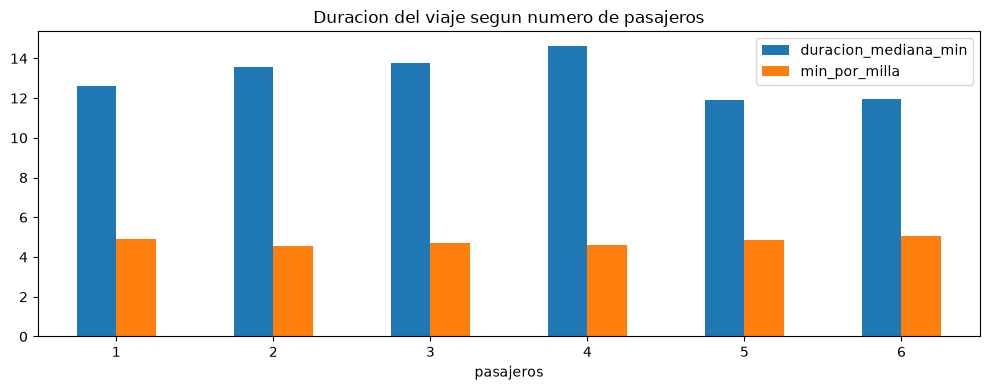

**Interpretacion:** Con 2024-2026 la duracion mediana sube de 12.6 min con 1 pasajero a 14.6 min con 4, pero la distancia media tambien sube (3.4 a 4.2 millas) y los minutos por milla bajan (4.89 a 4.60). Los grupos no viajan mas lento: hacen viajes mas largos. Con 5 y 6 pasajeros (vehiculos grandes) los viajes vuelven a ser cortos (12 min). No hay evidencia de que llevar mas pasajeros aumente el tiempo por si mismo.

In [3]:
resultados["01_pasajeros_duracion"] = indicador(con, "01_pasajeros_duracion")

## 2. Duracion promedio del viaje por mes

**Pregunta:** Cuanto dura en promedio un viaje y como cambia entre meses, anios y servicios?

**Justificacion:** La duracion (hora final menos hora inicial) resume congestion y tipo de recorrido; verla por mes permite comparar anios.

**Indicador:** Duracion media y mediana (min) por mes y tipo de taxi.

<details><summary>Consulta SQL</summary>

```sql
SELECT make_date(anio, mes, 1) AS fecha,
       tipo_taxi,
       count(*) AS viajes,
       round(avg(duracion_min), 2) AS duracion_media_min,
       round(median(duracion_min), 2) AS duracion_mediana_min
FROM viajes_validos
GROUP BY ALL
ORDER BY fecha, tipo_taxi;
```
</details>

,fecha,tipo_taxi,viajes,duracion_media_min,duracion_mediana_min
0,2024-01-01,green,53363,13.88,11.45
1,2024-01-01,yellow,2870280,14.97,11.72
2,2024-02-01,green,50429,14.04,11.47
3,2024-02-01,yellow,2904700,15.36,12.07
4,2024-03-01,green,54128,14.26,11.65
5,2024-03-01,yellow,3452875,16.11,12.55
6,2024-04-01,green,52961,14.29,11.72
7,2024-04-01,yellow,3426737,16.45,12.90
8,2024-05-01,green,57505,15.34,12.42
9,2024-05-01,yellow,3627413,17.49,13.43


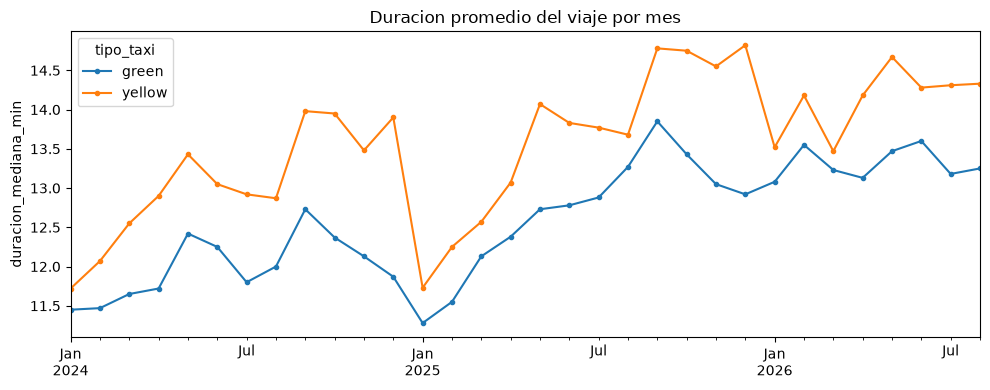

**Interpretacion:** La duracion mediana anual de Yellow sube de 13.1 min (2024) a 13.7 (2025) y 14.1 (2026), y Green muestra la misma tendencia (enero: 11.5, 11.3 y 13.1 min). Parte del aumento se debe a que crecen los registros sin datos del taximetro, que son viajes mas largos: en viajes con tarifa estandar (enero-agosto) la duracion mediana casi no cambia entre 2024 y 2025 (11.9 y 11.7 min) y sube en 2026 (12.2 min) porque la velocidad baja de 9.2 a 8.7 mph (ver Ejercicio 8). En 2024 y 2025 la duracion crece de enero a mayo y alcanza sus maximos entre septiembre y diciembre.

In [4]:
resultados["02_duracion_mensual"] = indicador(con, "02_duracion_mensual")

## 3. Tarifa base segun forma de pago

**Pregunta:** Con que forma de pago la tarifa base es mas alta?

**Justificacion:** Si una forma de pago se asocia a viajes mas caros, la mezcla de pagos influye en los ingresos; la distancia media ayuda a explicar la diferencia.

**Indicador:** Tarifa base media y mediana (USD) y distancia media por forma de pago y anio.

<details><summary>Consulta SQL</summary>

```sql
SELECT CAST(anio AS VARCHAR) AS anio,
       CASE payment_type
           WHEN 1 THEN 'tarjeta' WHEN 2 THEN 'efectivo' WHEN 3 THEN 'sin_cargo'
           WHEN 4 THEN 'disputa' WHEN 0 THEN 'sin_dato (0)' ELSE 'otro'
       END AS forma_pago,
       count(*) AS viajes,
       round(avg(fare_amount), 2) AS tarifa_base_media,
       round(median(fare_amount), 2) AS tarifa_base_mediana,
       round(avg(trip_distance), 2) AS distancia_media
FROM viajes_validos
WHERE fare_amount > 0
GROUP BY ALL
ORDER BY anio, viajes DESC;
```
</details>

,anio,forma_pago,viajes,tarifa_base_media,tarifa_base_mediana,distancia_media
0,2024,tarjeta,30598065,19.70,13.50,3.56
1,2024,efectivo,5444711,19.55,12.80,3.39
2,2024,sin_dato (0),3693052,20.53,18.08,19.32
3,2024,disputa,386503,22.25,12.80,3.85
4,2024,sin_cargo,158033,21.75,11.40,3.24
5,2024,otro,23693,25.69,20.36,388.19
6,2025,tarjeta,30714956,19.67,13.50,3.56
7,2025,sin_dato (0),8846293,21.24,18.79,18.66
8,2025,efectivo,4416197,19.62,12.80,3.42
9,2025,disputa,532174,25.30,13.50,4.49


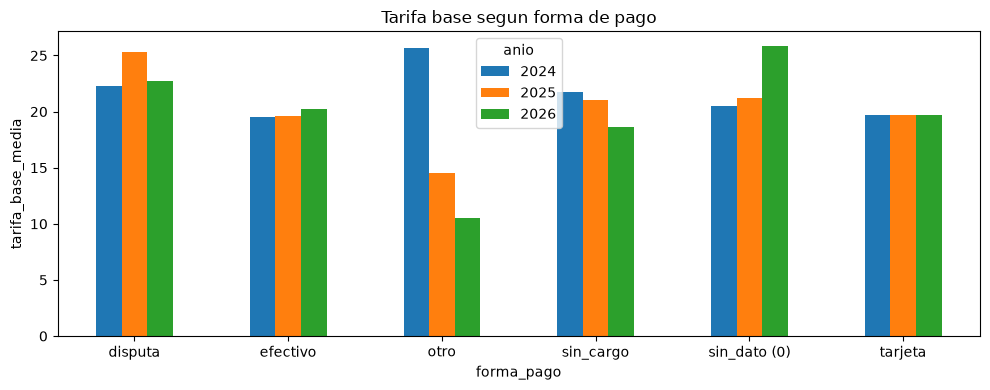

**Interpretacion:** Tarjeta y efectivo tienen practicamente la misma tarifa base en los tres anios (mediana USD 12.80-13.50): la forma de pago no determina el precio. La tarifa mas alta esta en el codigo 0 (mediana USD 18.08, 18.79 y 23.19 en 2024, 2025 y 2026), que agrupa registros sin datos del taximetro, incluidos los viajes por plataforma, que son mas largos; ademas este grupo crecio de 3.7 a 8.8 millones de viajes entre 2024 y 2025. Disputa tiene la media mas alta entre los codigos normales, pero su mediana (USD 12.80-13.50) no supera a la de tarjeta: la diferencia la producen pocos viajes caros.

In [5]:
resultados["03_pago_tarifa"] = indicador(con, "03_pago_tarifa")

## 4. Tarifa base segun origen de la solicitud

**Pregunta:** Los viajes pedidos por plataforma (Uber, Lyft u otras) tienen una tarifa base mas alta que los demas?

**Justificacion:** request_source existe solo en Yellow desde junio de 2026; HV0003 y HV0005 son las licencias TLC de Uber y Lyft. Se usa la tarifa por milla para separar el precio de la distancia. No se compara propina porque en viajes por plataforma no se registra (llega como 0).

**Indicador:** Participacion y medianas de tarifa base, distancia, duracion y tarifa por milla por origen de solicitud.

<details><summary>Consulta SQL</summary>

```sql
WITH periodo AS (
    SELECT * FROM viajes_validos
    WHERE tipo_taxi = 'yellow'
      AND make_date(anio, mes, 1) >= (
          SELECT min(make_date(anio, mes, 1)) FROM viajes WHERE request_source IS NOT NULL)
)
SELECT CASE request_source
           WHEN 'HV0003' THEN 'Uber' WHEN 'HV0005' THEN 'Lyft'
           ELSE CASE WHEN request_source IS NULL THEN 'sin plataforma' ELSE 'otras plataformas' END
       END AS origen,
       count(*) AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (), 2) AS pct_viajes,
       round(median(fare_amount), 2) AS tarifa_base_mediana,
       round(median(trip_distance), 2) AS distancia_mediana,
       round(median(duracion_min), 2) AS duracion_mediana_min,
       round(median(fare_amount / trip_distance), 2) AS tarifa_por_milla_mediana,
       round(avg(trip_distance), 2) AS distancia_media
FROM periodo
WHERE fare_amount > 0
GROUP BY origen
ORDER BY viajes DESC;
```
</details>

,origen,viajes,pct_viajes,tarifa_base_mediana,distancia_mediana,duracion_mediana_min,tarifa_por_milla_mediana,distancia_media
0,sin plataforma,7516388,74.03,13.50,1.70,12.88,7.53,3.34
1,Uber,2092550,20.61,22.98,3.03,17.13,7.17,12.14
2,otras plataformas,381679,3.76,21.66,3.60,20.55,5.92,9.87
3,Lyft,162333,1.60,23.36,4.88,22.98,4.68,5.98


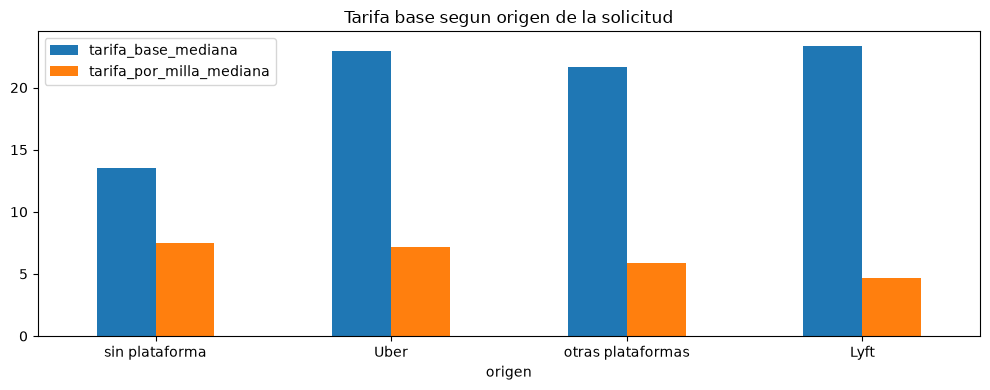

**Interpretacion:** request_source solo trae datos desde junio de 2026 (en 2024 y 2025 no existe). En junio-agosto de 2026, el 26 % de los viajes Yellow llego por plataforma (Uber 20.6 %, Lyft 1.6 %, otras 3.8 %). Su tarifa base mediana es mucho mayor (Uber USD 22.98 vs USD 13.50 sin plataforma), pero porque son viajes mas largos (3.0 vs 1.7 millas): la tarifa por milla de Uber (USD 7.17) es incluso algo menor que la de los viajes sin plataforma (USD 7.53). Las medias de distancia de las plataformas estan infladas por valores extremos, por eso se usan medianas.

In [6]:
resultados["04_origen_solicitud"] = indicador(con, "04_origen_solicitud")

## 5. Propina segun distancia del viaje

**Pregunta:** Los pasajeros dejan proporcionalmente mas propina en viajes cortos o largos?

**Justificacion:** Reemplaza la comparacion de propina por origen, que no es posible porque las plataformas no registran propina. Solo se usan pagos con tarjeta, unicos con propina registrada.

**Indicador:** Propina como porcentaje de la tarifa y porcentaje de viajes con propina por rango de distancia.

<details><summary>Consulta SQL</summary>

```sql
SELECT CAST(anio AS VARCHAR) AS anio,
       CASE
           WHEN trip_distance < 1 THEN '1) < 1 mi'
           WHEN trip_distance < 2 THEN '2) 1-2 mi'
           WHEN trip_distance < 5 THEN '3) 2-5 mi'
           WHEN trip_distance < 10 THEN '4) 5-10 mi'
           WHEN trip_distance < 20 THEN '5) 10-20 mi'
           ELSE '6) 20+ mi'
       END AS rango_distancia,
       count(*) AS viajes,
       round(avg(tip_amount), 2) AS propina_media,
       round(100.0 * sum(tip_amount) / sum(fare_amount), 2) AS propina_pct_tarifa,
       round(100.0 * avg(CASE WHEN tip_amount > 0 THEN 1 ELSE 0 END), 2) AS pct_con_propina
FROM viajes_validos
WHERE payment_type = 1 AND fare_amount > 0 AND tip_amount >= 0
GROUP BY ALL
ORDER BY anio, rango_distancia;
```
</details>

,anio,rango_distancia,viajes,propina_media,propina_pct_tarifa,pct_con_propina
0,2024,1) < 1 mi,6729621,2.33,28.72,95.09
1,2024,2) 1-2 mi,10353704,2.98,24.89,95.90
2,2024,3) 2-5 mi,8317760,4.21,21.67,95.02
3,2024,4) 5-10 mi,2585661,7.36,20.74,90.17
4,2024,5) 10-20 mi,2284599,11.95,19.31,88.36
5,2024,6) 20+ mi,326720,15.34,17.05,88.02
6,2025,1) < 1 mi,6997591,2.42,29.27,94.49
7,2025,2) 1-2 mi,10305095,3.04,25.43,95.18
8,2025,3) 2-5 mi,8137573,4.23,21.79,93.47
9,2025,4) 5-10 mi,2671914,7.13,19.96,85.67


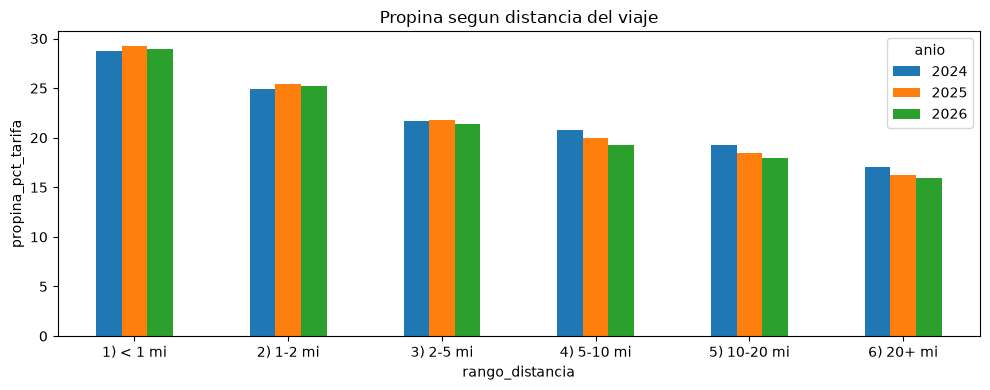

**Interpretacion:** La propina en proporcion a la tarifa disminuye con la distancia: cerca de 29 % en viajes de menos de 1 milla y 16-17 % en viajes de mas de 20 millas, aunque en dolares crece. La proporcion de viajes con propina cae ano a ano en viajes medios y largos: en 5-10 millas pasa de 90.2 % (2024) a 85.7 % (2025) y 81.5 % (2026), y en mas de 20 millas de 88.0 % a 78.7 %, mientras en viajes de menos de 1 milla se mantiene en 94-95 %.

In [7]:
resultados["05_propina_distancia"] = indicador(con, "05_propina_distancia")

## 6. Uso y costo de cada tipo de tarifa

**Pregunta:** Que tipos de tarifa (estandar, aeropuertos, negociada) se usan y cual tiene la tarifa base mas alta?

**Justificacion:** Reemplaza la relacion tipo de tarifa - origen de solicitud, que no es medible porque los viajes por plataforma no informan RatecodeID. Las tarifas especiales explican buena parte de los viajes caros.

**Indicador:** Porcentaje de viajes, tarifa base media, distancia y duracion media por tipo de tarifa.

<details><summary>Consulta SQL</summary>

```sql
WITH resumen AS (
    SELECT CAST(anio AS VARCHAR) AS anio,
           CASE ratecode_id
               WHEN 1 THEN '1 estandar' WHEN 2 THEN '2 JFK' WHEN 3 THEN '3 Newark'
               WHEN 4 THEN '4 Nassau/Westchester' WHEN 5 THEN '5 negociada'
               WHEN 6 THEN '6 grupal' ELSE '99 desconocida'
           END AS tipo_tarifa,
           count(*) AS viajes,
           round(avg(fare_amount), 2) AS tarifa_base_media,
           round(avg(trip_distance), 2) AS distancia_media,
           round(avg(duracion_min), 2) AS duracion_media_min
    FROM viajes_validos
    WHERE ratecode_id IS NOT NULL AND fare_amount > 0
    GROUP BY ALL
)
SELECT anio, tipo_tarifa, viajes,
       round(100.0 * viajes / sum(viajes) OVER (PARTITION BY anio), 2) AS pct_viajes,
       tarifa_base_media, distancia_media, duracion_media_min
FROM resumen
ORDER BY anio, tipo_tarifa;
```
</details>

,anio,tipo_tarifa,viajes,pct_viajes,tarifa_base_media,distancia_media,duracion_media_min
0,2024,1 estandar,34416810,94.07,16.79,2.69,14.88
1,2024,2 JFK,1331954,3.64,70.00,17.92,51.74
2,2024,3 Newark,116552,0.32,87.73,16.58,39.75
3,2024,4 Nassau/Westchester,96721,0.26,114.41,22.06,42.95
4,2024,5 negociada,185856,0.51,75.43,11.65,25.50
5,2024,6 grupal,22,0.00,3.86,2.68,14.70
6,2024,99 desconocida,439418,1.20,33.80,15.37,49.49
7,2025,1 estandar,33307702,92.97,16.55,2.63,14.64
8,2025,2 JFK,1207472,3.37,70.54,17.75,52.53
9,2025,3 Newark,125522,0.35,78.79,14.13,36.07


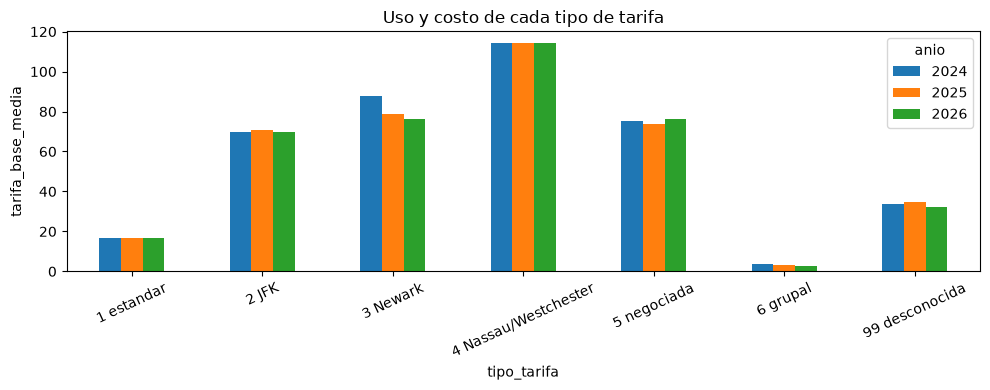

**Interpretacion:** La tarifa estandar cubre la gran mayoria de los viajes, pero su participacion baja de 94.1 % a 93.0 % y 91.9 % entre 2024 y 2026. JFK se mantiene cerca de USD 70 (tarifa fija) y Nassau/Westchester es la mas cara (USD 114). Newark bajo de USD 87.7 a 78.8 y 76.2. La categoria desconocida (99) crece cada anio (1.2 %, 2.2 % y 3.6 %), lo que indica una perdida de calidad en este campo.

In [8]:
resultados["06_tipo_tarifa"] = indicador(con, "06_tipo_tarifa")

## 7. Zonas de destino con mayor y menor propina

**Pregunta:** Hay destinos donde los pasajeros dejan una propina mas alta?

**Justificacion:** El destino refleja el tipo de viaje (aeropuerto, oficinas, ocio, zonas residenciales). Solo pagos con tarjeta y zonas con al menos 10,000 viajes para evitar porcentajes inestables. Se muestran ambos extremos porque el contraste esta entre ellos.

**Indicador:** Propina como porcentaje de la tarifa por zona de destino (10 mas altas y 10 mas bajas).

<details><summary>Consulta SQL</summary>

```sql
WITH por_destino AS (
    SELECT z.zona || ' (' || z.barrio || ')' AS destino,
           count(*) AS viajes,
           round(avg(v.tip_amount), 2) AS propina_media,
           round(100.0 * sum(v.tip_amount) / sum(v.fare_amount), 2) AS propina_pct_tarifa
    FROM viajes_validos AS v
    JOIN zonas AS z ON z.zona_id = v.destino_id
    WHERE v.payment_type = 1 AND v.fare_amount > 0 AND v.tip_amount >= 0
      AND z.zona NOT IN ('N/A', 'Outside of NYC')
    GROUP BY destino
    HAVING count(*) >= 10000
), ranking AS (
    SELECT *,
           row_number() OVER (ORDER BY propina_pct_tarifa DESC) AS desde_arriba,
           row_number() OVER (ORDER BY propina_pct_tarifa) AS desde_abajo
    FROM por_destino
)
SELECT CASE WHEN desde_arriba <= 10 THEN 'mas alta' ELSE 'mas baja' END AS grupo,
       destino, viajes, propina_media, propina_pct_tarifa
FROM ranking
WHERE desde_arriba <= 10 OR desde_abajo <= 10
ORDER BY propina_pct_tarifa DESC;
```
</details>

,grupo,destino,viajes,propina_media,propina_pct_tarifa
0,mas alta,Upper East Side South (Manhattan),3688100,3.31,24.96
1,mas alta,Upper West Side South (Manhattan),2359661,3.88,24.62
2,mas alta,Lincoln Square East (Manhattan),2298378,3.69,24.58
3,mas alta,Greenwich Village North (Manhattan),1064685,3.95,24.58
4,mas alta,Upper East Side North (Manhattan),3899870,3.42,24.56
5,mas alta,West Village (Manhattan),1444357,3.57,24.43
6,mas alta,Penn Station/Madison Sq West (Manhattan),1654700,3.84,24.39
7,mas alta,Central Park (Manhattan),886708,3.67,24.36
8,mas alta,Flatiron (Manhattan),1194768,3.81,24.28
9,mas alta,Union Sq (Manhattan),2008257,3.53,24.28


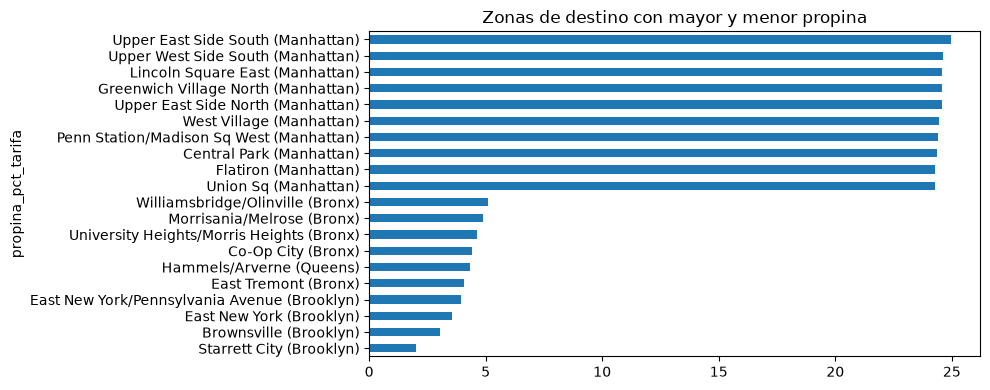

**Interpretacion:** Las 10 zonas con mayor propina estan todas en Manhattan (Upper East/West Side, Village, Midtown), con 24.3-25.0 % de la tarifa y muy poca variacion entre ellas. El contraste esta en el otro extremo: en destinos de Brooklyn, Bronx y Queens como Starrett City (2.0 %), Brownsville (3.0 %) o East New York (3.6 %) la propina registrada es 5 a 12 veces menor. El destino si se asocia con la propina, y la diferencia es entre Manhattan y zonas perifericas.

In [9]:
resultados["07_destino_propina"] = indicador(con, "07_destino_propina")

## 8. Demanda mensual de viajes

**Pregunta:** Como evoluciona la cantidad de viajes por mes y anio en Yellow y Green?

**Justificacion:** Es el indicador base de actividad; se usa viajes por dia para comparar meses de distinta longitud y meses parciales.

**Indicador:** Viajes por dia por mes y tipo de taxi (todos los registros con fecha dentro del anio del archivo).

<details><summary>Consulta SQL</summary>

```sql
WITH mensual AS (
    SELECT make_date(anio, mes, 1) AS fecha, tipo_taxi, count(*) AS viajes
    FROM viajes
    WHERE year(pickup_datetime) = anio
    GROUP BY ALL
)
SELECT fecha, tipo_taxi, viajes,
       round(viajes / day(last_day(fecha)), 1) AS viajes_por_dia
FROM mensual
ORDER BY fecha, tipo_taxi;
```
</details>

,fecha,tipo_taxi,viajes,viajes_por_dia
0,2024-01-01,green,56549,"1,824.20"
1,2024-01-01,yellow,2964609,"95,632.50"
2,2024-02-01,green,53577,"1,847.50"
3,2024-02-01,yellow,3007524,"103,707.70"
4,2024-03-01,green,57455,"1,853.40"
5,2024-03-01,yellow,3582626,"115,568.60"
6,2024-04-01,green,56471,"1,882.40"
7,2024-04-01,yellow,3514285,"117,142.80"
8,2024-05-01,green,61001,"1,967.80"
9,2024-05-01,yellow,3723826,"120,123.40"


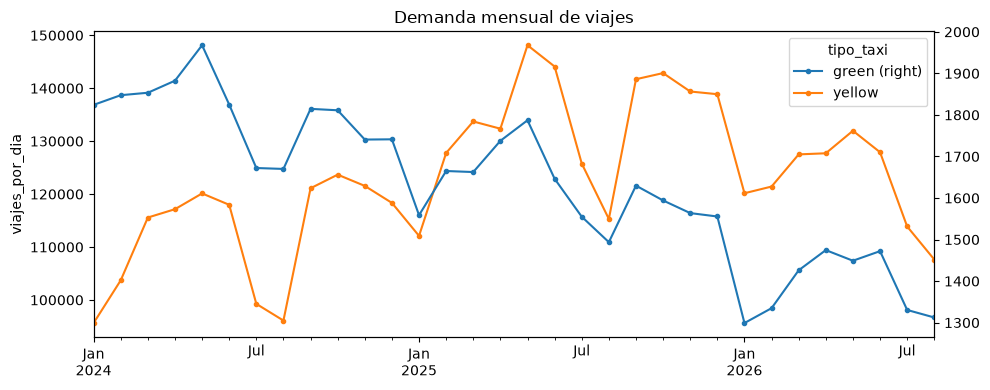

**Interpretacion:** El total de Yellow alcanza su maximo en 2025: cada mes supera al mismo mes de 2024 (mayo: 148 mil vs 120 mil viajes por dia) y de febrero a agosto de 2026 queda por debajo de 2025 (mayo: 132 mil). Ese crecimiento no proviene de viajes con taximetro, que solo suben 2 % en 2025 y caen 9 % en 2026 (enero-agosto), sino de los registros sin datos del taximetro, que se triplican (ver Ejercicio 8). Green cae de forma continua: cada mes de 2025 es menor que el de 2024 y cada mes de 2026 menor que el de 2025 (agosto: 1,670, 1,494 y 1,312 viajes por dia). En los tres anios la demanda baja en julio-agosto.

In [10]:
resultados["08_demanda_mensual"] = indicador(con, "08_demanda_mensual")

## 9. Demanda por hora y dia de la semana

**Pregunta:** En que horas y dias se concentra la demanda?

**Justificacion:** Muestra los picos operativos que el total mensual oculta. Se usa el porcentaje dentro de cada dia para comparar la forma de la curva.

**Indicador:** Porcentaje de los viajes de cada dia de la semana que ocurre en cada hora.

<details><summary>Consulta SQL</summary>

```sql
WITH conteo AS (
    SELECT isodow(pickup_datetime) AS dow, hour(pickup_datetime) AS hora, count(*) AS viajes
    FROM viajes_validos
    GROUP BY ALL
)
SELECT hora,
       ['1 Lun', '2 Mar', '3 Mie', '4 Jue', '5 Vie', '6 Sab', '7 Dom'][dow] AS dia_semana,
       viajes,
       round(100.0 * viajes / sum(viajes) OVER (PARTITION BY dow), 2) AS pct_del_dia
FROM conteo
ORDER BY dia_semana, hora;
```
</details>

,hora,dia_semana,viajes,pct_del_dia
0,0,1 Lun,265496,1.88
1,1,1 Lun,135280,0.96
2,2,1 Lun,77157,0.55
3,3,1 Lun,57584,0.41
4,4,1 Lun,75089,0.53
5,5,1 Lun,134444,0.95
6,6,1 Lun,291843,2.07
7,7,1 Lun,541459,3.84
8,8,1 Lun,714131,5.07
9,9,1 Lun,701748,4.98


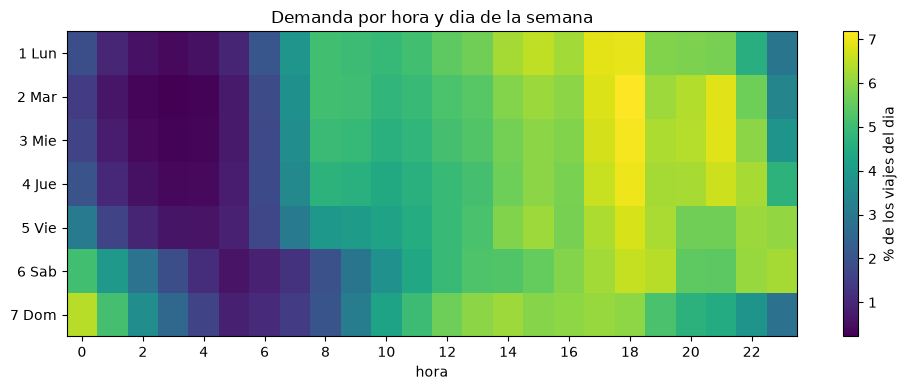

**Interpretacion:** De lunes a viernes hay un pico matutino a las 8 h (5 % de los viajes del dia) y el maximo entre las 17 y 18 h (7 %). Sabado y domingo no tienen pico matutino y concentran viajes en la madrugada: el domingo entre 0 y 2 h ocurre 15 % de sus viajes, frente a 2 % del martes, porque recoge la salida nocturna del sabado. Jueves a sabado mantienen demanda alta hasta las 23 h.

In [11]:
resultados["09_hora_dia_semana"] = indicador(con, "09_hora_dia_semana")

## 10. Peaje de congestion del centro de Manhattan

**Pregunta:** Que proporcion de viajes paga el peaje de congestion del centro y cuanto recauda por mes?

**Justificacion:** El peaje (cbd_congestion_fee) empezo en enero de 2025; comparar anios muestra el efecto de la politica en los viajes de taxi.

**Indicador:** Porcentaje de viajes con cbd_congestion_fee > 0 y recaudacion mensual (USD) por tipo de taxi.

<details><summary>Consulta SQL</summary>

```sql
SELECT make_date(anio, mes, 1) AS fecha,
       tipo_taxi,
       count(*) AS viajes,
       round(100.0 * avg(CASE WHEN cbd_congestion_fee > 0 THEN 1 ELSE 0 END), 2) AS pct_viajes_con_cargo,
       round(sum(cbd_congestion_fee), 2) AS recaudacion_usd
FROM viajes
WHERE year(pickup_datetime) = anio
GROUP BY ALL
ORDER BY fecha, tipo_taxi;
```
</details>

,fecha,tipo_taxi,viajes,pct_viajes_con_cargo,recaudacion_usd
0,2024-01-01,green,56549,0.00,0.00
1,2024-01-01,yellow,2964609,0.00,0.00
2,2024-02-01,green,53577,0.00,0.00
3,2024-02-01,yellow,3007524,0.00,0.00
4,2024-03-01,green,57455,0.00,0.00
5,2024-03-01,yellow,3582626,0.00,0.00
6,2024-04-01,green,56471,0.00,0.00
7,2024-04-01,yellow,3514285,0.00,0.00
8,2024-05-01,green,61001,0.00,0.00
9,2024-05-01,yellow,3723826,0.00,0.00


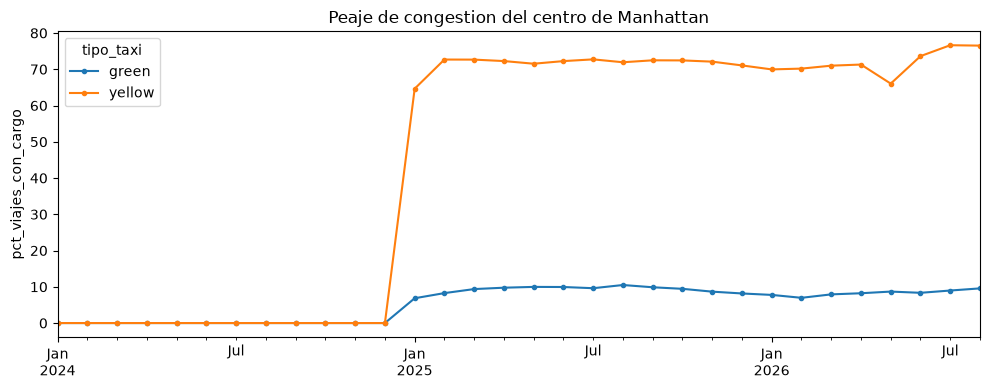

**Interpretacion:** El peaje no existe en 2024 (0 %) y aparece en enero de 2025, cuando ya lo paga el 64.6 % de los viajes Yellow (empezo el 5 de enero); desde febrero de 2025 se estabiliza en 71-73 % y en julio-agosto de 2026 sube a 77 %. Recauda en Yellow entre USD 1.7 y 2.4 millones por mes. En Green solo lo paga 7-10 % de los viajes (unos USD 2-4 mil por mes), coherente con que opera principalmente fuera del centro de Manhattan.

In [12]:
resultados["10_cargo_congestion"] = indicador(con, "10_cargo_congestion")

## 7.5 Tablero

Los diez indicadores en una sola vista. La misma organizacion se replica en el
tablero de Metabase.

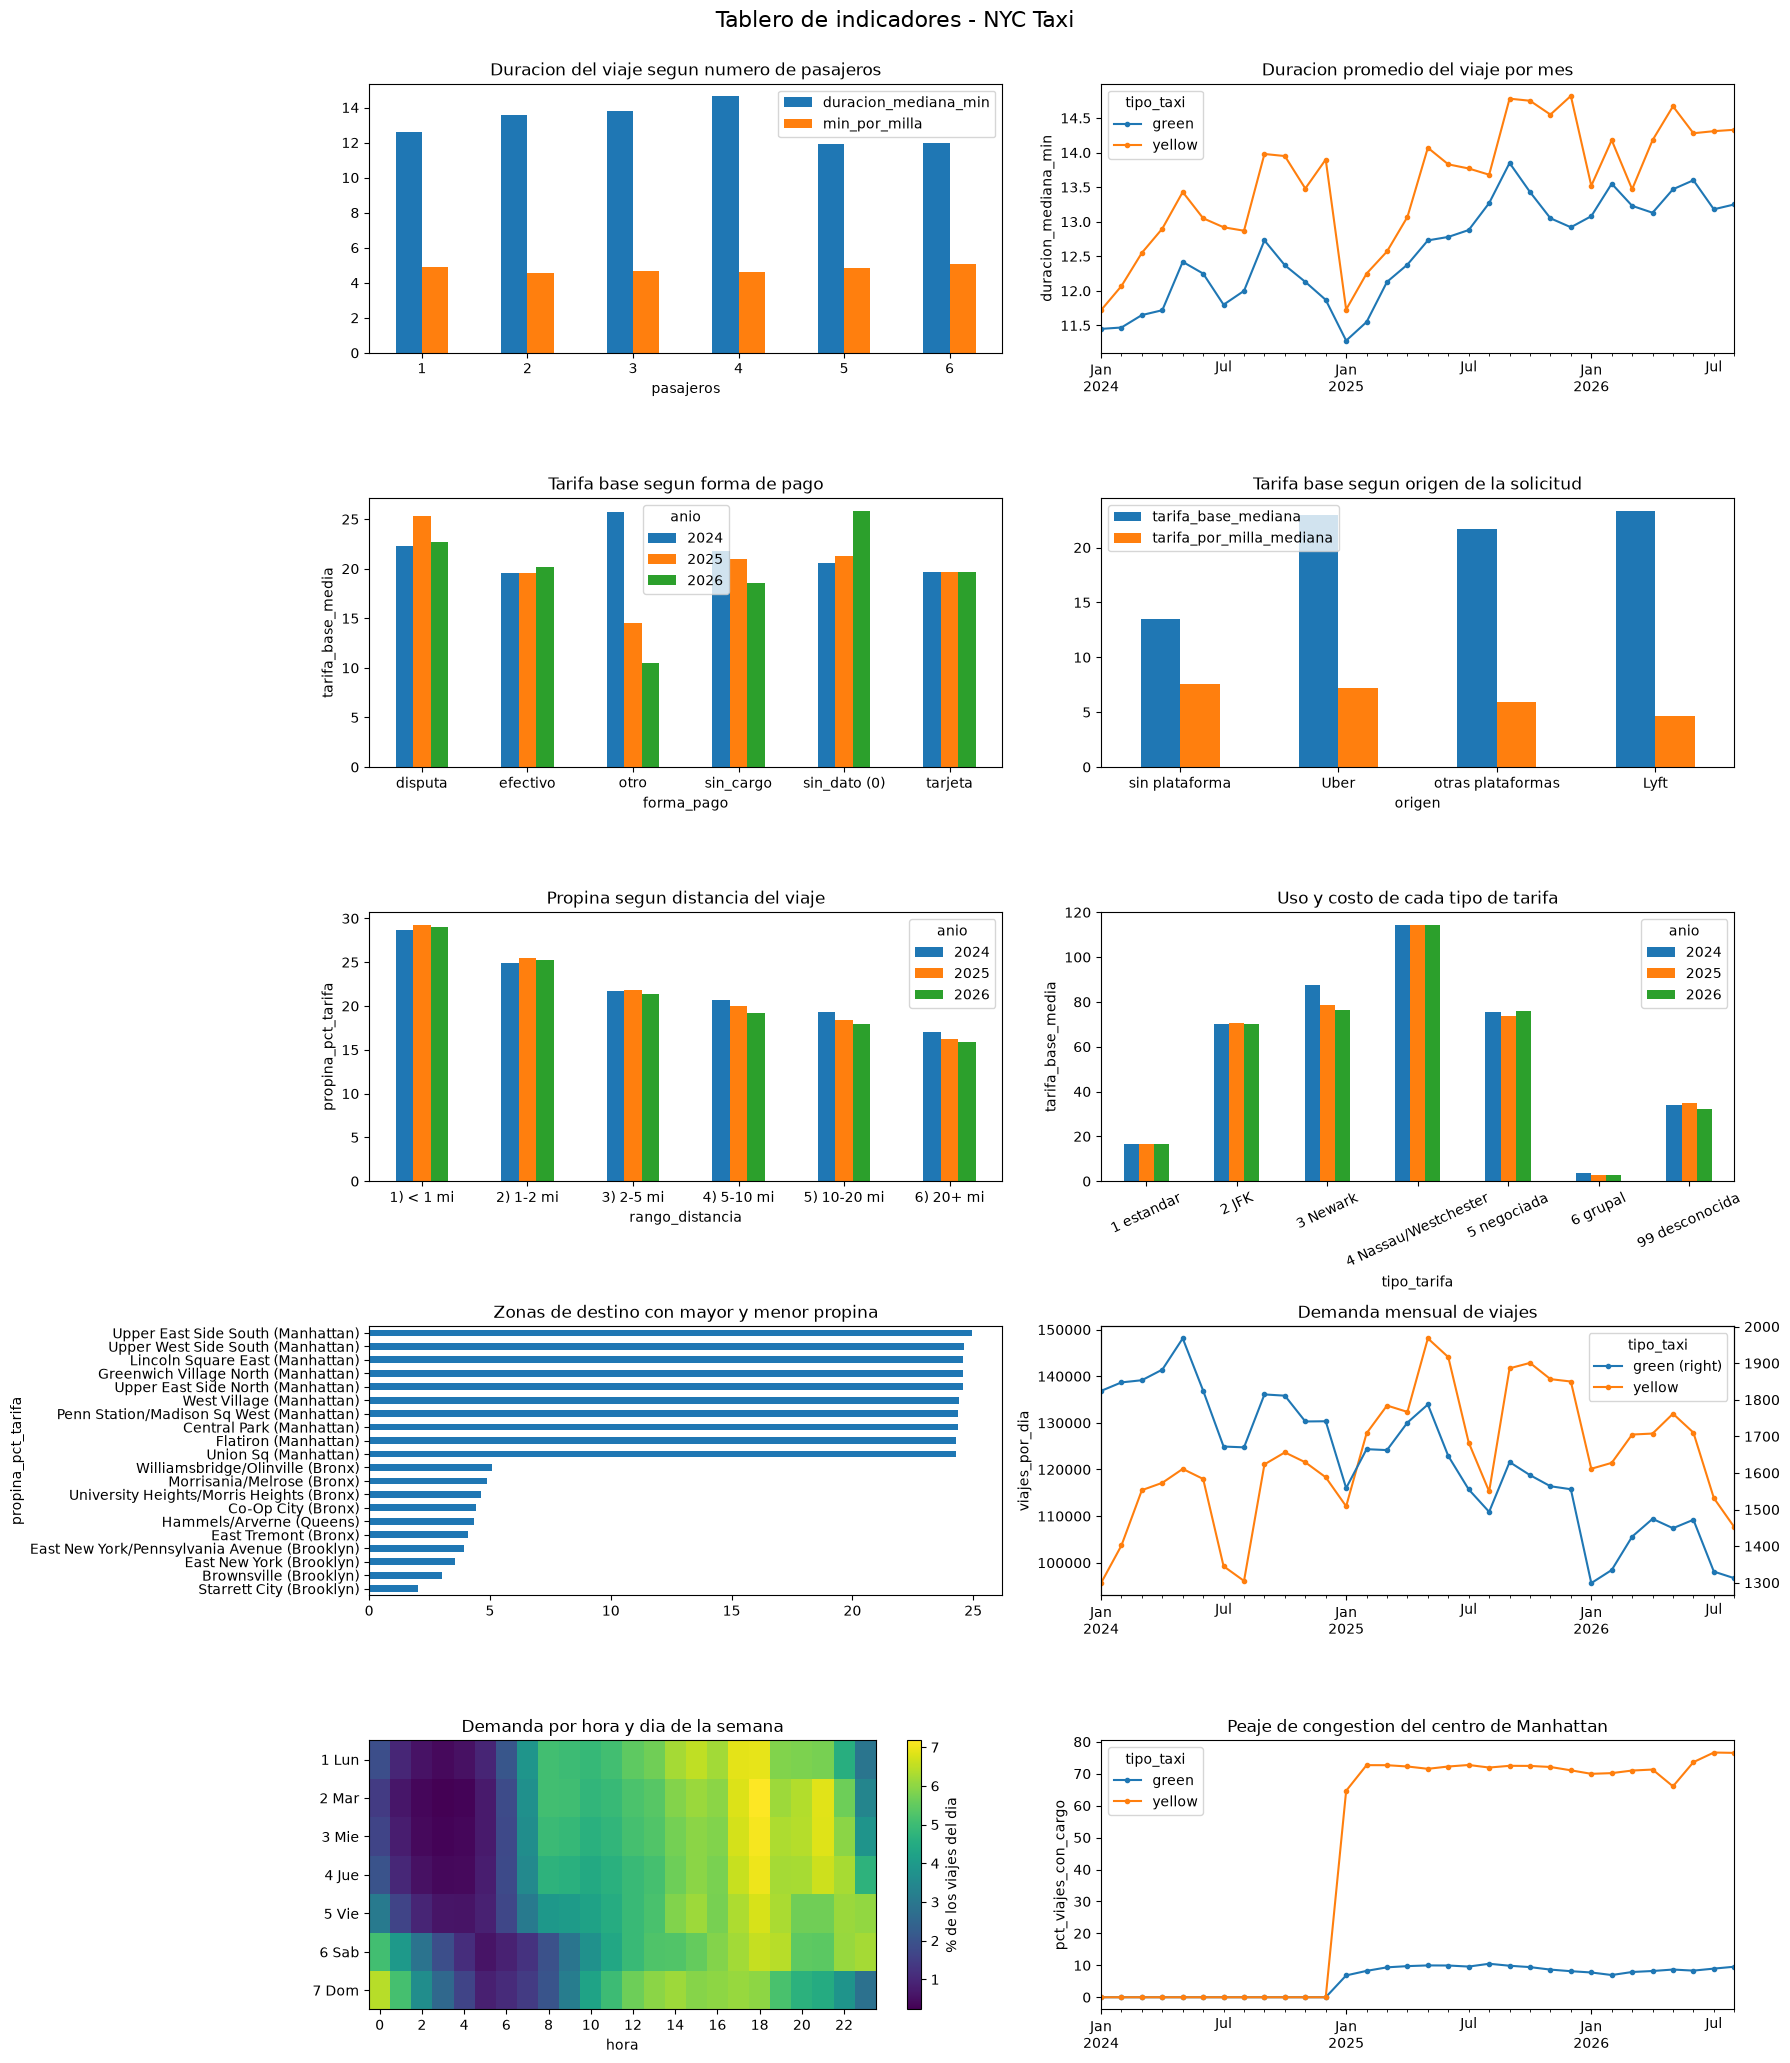

In [13]:
tablero(resultados);

## 7.8 Principales hallazgos

1. **El total de Yellow tuvo su maximo en 2025, pero no por taxis tradicionales.** En
   mayo paso de 120 mil viajes por dia (2024) a 148 mil (2025) y bajo a 132 mil (2026);
   el crecimiento viene de los registros sin datos del taximetro, que se triplican,
   mientras los viajes con taximetro casi no cambian (ver Ejercicio 8). Green cae todos
   los anios.
2. **Los viajes duran mas, sobre todo en 2026.** La duracion mediana anual de Yellow sube
   de 13.1 a 13.7 y 14.1 min; en viajes con tarifa estandar la velocidad es igual en 2024
   y 2025 y baja 6 % en 2026.
3. **El peaje de congestion alcanza a la mayoria de los viajes Yellow.** Aparece en
   enero de 2025 y desde entonces lo paga 71-77 % de los viajes Yellow (USD 1.7-2.4
   millones por mes); en Green solo 7-10 %.
4. **Las plataformas no cobran mas por milla.** Los viajes pedidos por Uber o Lyft
   tienen tarifa base mas alta solo porque son mas largos.
5. **La propina depende del destino y de la distancia.** En destinos de Manhattan
   ronda el 24-25 % de la tarifa y en zonas perifericas de Brooklyn, Bronx o Queens cae
   a 2-5 %; ademas, la propina proporcional disminuye en viajes largos y cada anio menos
   viajes largos registran propina.
6. **El numero de pasajeros no alarga el viaje por si mismo:** los grupos recorren
   mas distancia, pero a igual o mayor velocidad.

In [14]:
con.close()  # libera la base para poder reconstruirla